# Offsite Test for Data Analyst Internship

Package used: pandas, duckdb, matplotlib, seaborn

In [30]:
run = False

### Load Libraries

In [31]:
import pandas as pd
import duckdb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime



import warnings
warnings.filterwarnings('ignore')

### Data preprocessing

Before proceeding with the analysis, we first identified null values in each row, excluding ctm_customer_id, where NA indicates a non-member.

In [32]:
#read csv
df = pd.read_csv("/Users/kohziyang/Documents/dec_data/Recruitment_Transactions_ToBeDistributed.csv")

#transfer datetime
df["the_date_transaction"] = pd.to_datetime(df["the_date_transaction"])

#identify NA value (except customer_id) and perform data cleaning
print(df.isnull().sum())

df = df[df["product_type"].notna()]
df = df[df["sports"].notna()]

df = df.drop(df.columns[[0]], axis = 1)


df

Unnamed: 0                      0
the_transaction_id              0
the_date_transaction            0
sku_idr_sku                     0
product_type                  878
sports                        656
but_name_business_unit          0
ctm_customer_id           2059281
the_to_type                     0
f_qty_item                      0
f_to_tax_in                     0
dtype: int64


,the_transaction_id,the_date_transaction,sku_idr_sku,product_type,sports,but_name_business_unit,ctm_customer_id,the_to_type,f_qty_item,f_to_tax_in
656,7-2128-2128-20201128223450-101-8145,2020-11-28 22:34:50,1795606,UNDEFINED,RUGBY,Singapore Lab,NaN,offline,4,45.0
657,7-1034-1034-20200702133138-212-6643,2020-07-02 13:31:38,7200628,SHOES,RUNNING,City Square SG,NaN,offline,3,112.0
658,7-1034-1034-20200701183058-213-952,2020-07-01 18:30:58,7204159,WATER BAG,RUNNING,City Square SG,NaN,offline,3,218.0
659,7-1034-1034-20200701151855-215-8375,2020-07-01 15:18:55,7009513,SUNGLASSES,RUNNING,City Square SG,NaN,offline,2,41.5
660,7-1034-1034-20200704125639-206-1247,2020-07-04 12:56:39,7197010,SHOES,RUNNING,City Square SG,TALU7QD0XB,offline,3,81.5
...,...,...,...,...,...,...,...,...,...,...
5496746,7-969-969-20201226201312-211-8466,2020-12-26 20:13:12,2177227,SOCKS,RUNNING,Bedok SG,NA91D6G8HO,offline,4,8.0
5496747,7-969-969-20201230153254-211-8943,2020-12-30 15:32:54,6867239,SHOES,RUNNING,Bedok SG,NaN,offline,1,40.0
5496748,7-969-969-20201230184807-207-5820,2020-12-30 18:48:07,1202775,SOCKS,RUNNING,Bedok SG,F6G0ST0TX9,offline,1,123.0
5496749,7-969-969-20201230184807-207-5820,2020-12-30 18:48:07,2386363,SOCKS,RUNNING,Bedok SG,F6G0ST0TX9,offline,1,40.5


In [33]:
#helping function for sectionA


def group_by_store(store, df_given):
    '''
    this function are able to group the store together by using the given dataset
    '''
    df_store = df_given[df_given["but_name_business_unit"] == store]
    # df_store = df_store.drop(df_store.columns[[0]], axis = 1)
    return df_store




def group_by_basket(df_given):
    '''
    this function are able to combine all the basket that a particular customer purchase and come out with the sum of the item and value
    '''
    df_basket = duckdb.query(f"SELECT ANY_VALUE(but_name_business_unit) as Store, the_transaction_id, ROUND(SUM(f_qty_item), 2) as 'Basket Size',ROUND(SUM(f_to_tax_in),2) as 'Basket Value' FROM df_given GROUP BY the_transaction_id").df()
    return df_basket



### Section A

The average basket size and average basket value of members and non-members per store

In [34]:
#Q1 preprocessing


#identify member and non member
member = df[~df["ctm_customer_id"].isna()]

non_member = df[df["ctm_customer_id"].isna()]

#identify the name of the store
store = df["but_name_business_unit"].unique()

#store relevant information for each store in dictionary
store_member = {}
store_non_member = {}


#preprocessing, each store are associated with their average basket size and average basket value
for i in store:
    df_store_member = group_by_store(i, member)
    df_store_non_member = group_by_store(i, non_member)
    df_bas_member = group_by_basket(df_store_member)
    df_bas_non_member = group_by_basket(df_store_non_member)
    store_member[i] = df_bas_member.groupby("Store").agg(average_basket_size = ("Basket Size", "mean"), average_basket_value = ("Basket Value", "mean")).reset_index()
    store_non_member[i] = df_bas_non_member.groupby("Store").agg(average_basket_size = ("Basket Size", "mean"), average_basket_value = ("Basket Value", "mean")).reset_index()
store_member["Singapore Lab"]


# df_holland_member_stats = df_holland_member[["Average Basket Size"]].mean(axis = 1)
# df_holland_non_member_stats = df_holland_non_member[["Average Basket Size"]].mean(axis = 1)


,Store,average_basket_size,average_basket_value
0,Singapore Lab,13.817671,284.633059


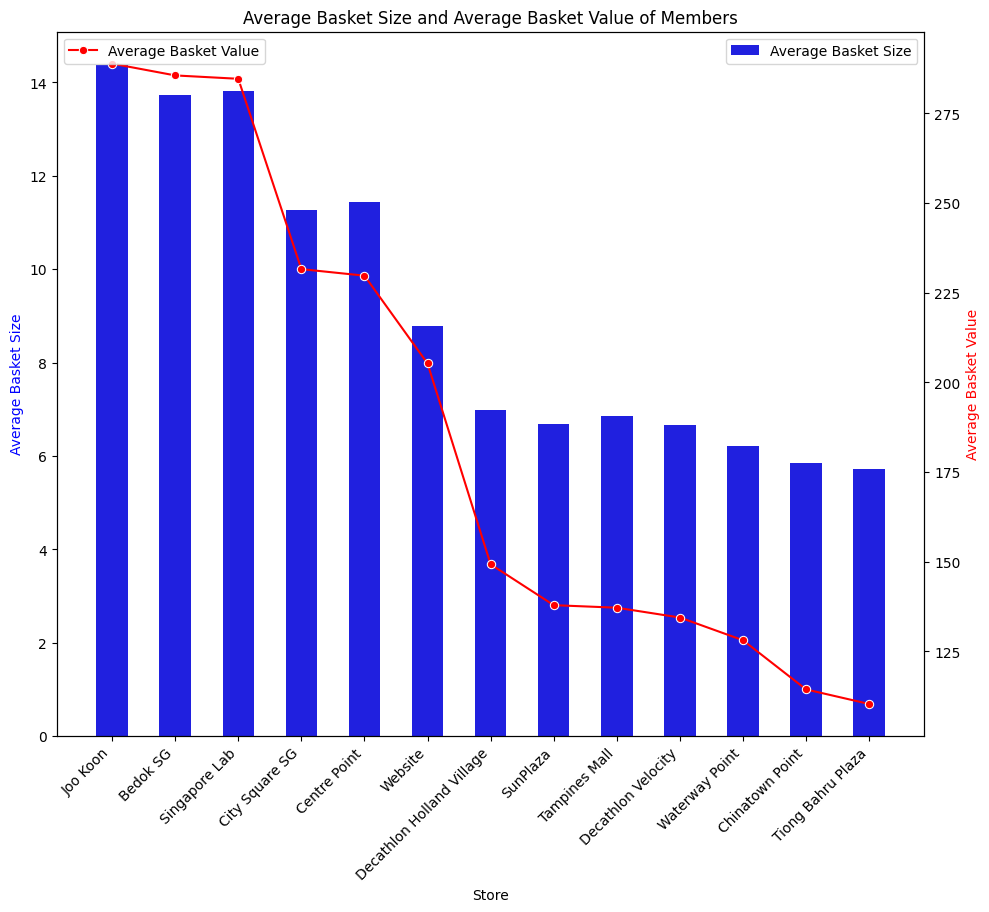

In [35]:
#visulisation for member 
df_list = []
for store, data in store_member.items():
    temp_df = data.copy()
    temp_df["Store"] = store 
    df_list.append(temp_df)

df_member = pd.concat(df_list, ignore_index=True)

avg_basket_size = df_member["average_basket_size"].mean()
avg_basket_value = df_member["average_basket_value"].mean()

df_member = df_member.sort_values(by="average_basket_value", ascending=False)


fig, ax1 = plt.subplots(figsize=(10, 8))

# Bar plot for average_basket_size
sns.barplot(x="Store", y="average_basket_size", data=df_member, color="b", ax=ax1, label="Average Basket Size", width = 0.5)

# Twin axis for average_basket_value
ax2 = ax1.twinx()
sns.lineplot(x="Store", y="average_basket_value", data=df_member, color="r", marker="o", ax=ax2, label="Average Basket Value")

# ax2.axhline(avg_basket_value, color="r", linestyle="--", linewidth=1.5, label="Avg Basket Value")

# Labels and titles
ax1.set_ylabel("Average Basket Size", color="b")
ax2.set_ylabel("Average Basket Value", color="r")
ax1.set_title("Average Basket Size and Average Basket Value of Members")

plt.tight_layout()
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
plt.legend(loc="upper left")
plt.show()
    

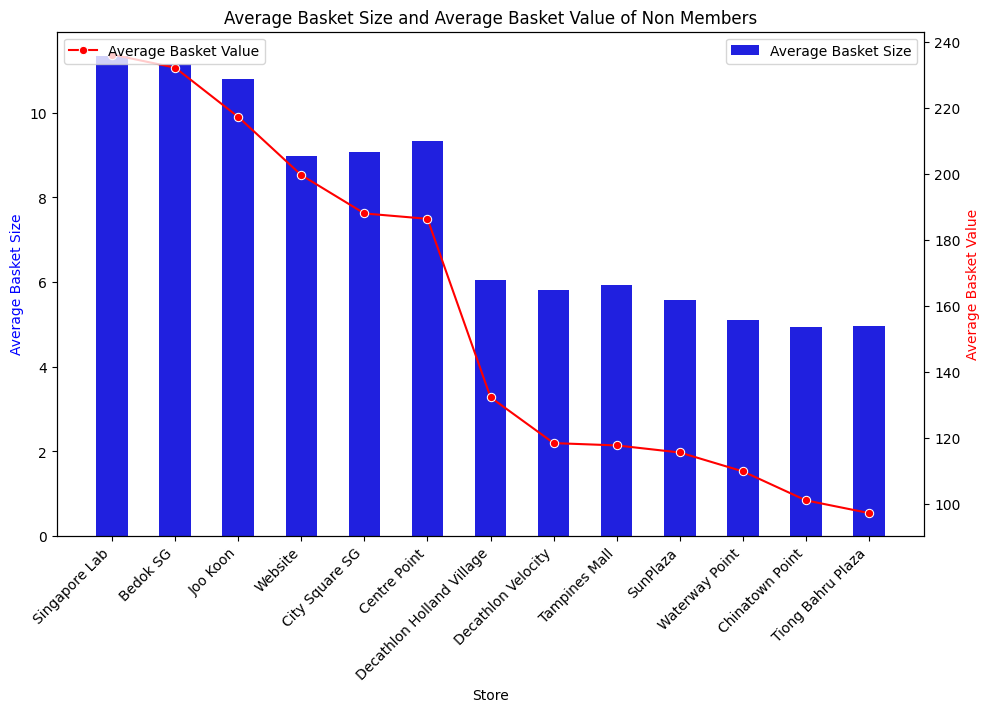

In [36]:
#visualisation for non member

df_list = []
for store, data in store_non_member.items():
    temp_df = data.copy()
    temp_df["Store"] = store  # Add store as a column
    df_list.append(temp_df)

df_member = pd.concat(df_list, ignore_index=True)

avg_basket_size = df_member["average_basket_size"].mean()
avg_basket_value = df_member["average_basket_value"].mean()

df_member = df_member.sort_values(by="average_basket_value", ascending=False)

# Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for average_basket_size
sns.barplot(x="Store", y="average_basket_size", data=df_member, color="b", ax=ax1, label="Average Basket Size", width = 0.5)


# Twin axis for average_basket_value
ax2 = ax1.twinx()
sns.lineplot(x="Store", y="average_basket_value", data=df_member, color="r", marker="o", ax=ax2, label="Average Basket Value")

# ax2.axhline(avg_basket_value, color="r", linestyle="--", linewidth=1.5, label=f"Avg Basket Value = {avg_basket_value}")

# Labels and titles
ax1.set_ylabel("Average Basket Size", color="b")
ax2.set_ylabel("Average Basket Value", color="r")
ax1.set_title("Average Basket Size and Average Basket Value of Non Members")

plt.tight_layout()
plt.xticks(rotation = 45)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
plt.legend(loc="upper left")
plt.show()

In [37]:
store_member

# coordinates for each Decathlon Store
coordinates = {
    'Singapore Lab': {'latitude': 1.3043937, 'longitude': 103.8823325},
    'City Square SG': {'latitude': 1.28967, 'longitude': 103.85007},
    'Joo Koon': {'latitude': 1.3272083, 'longitude': 103.6784809},
    'Decathlon Holland Village': {'latitude': 1.3111181, 'longitude': 103.7955874},
    'Decathlon Velocity': {'latitude': 1.3197981, 'longitude': 103.8440434},
    'Waterway Point': {'latitude': 1.4064265, 'longitude': 103.9020102},
    'SunPlaza': {'latitude': 1.448032, 'longitude': 103.819362},
    'Centre Point': {'latitude': 1.305141, 'longitude': 103.831675},
    'Tampines Mall': {'latitude': 1.352511, 'longitude': 103.944577},
    'Tiong Bahru Plaza': {'latitude': 1.2865, 'longitude': 103.8272},
    'Chinatown Point': {'latitude': 1.284901, 'longitude': 103.844465},
    'Bedok SG': {'latitude': 1.323036, 'longitude': 103.922081}
}

for store, df_store in store_member.items():
    if store in coordinates:
        df_store['latitude'] = coordinates[store]['latitude']
        df_store['longitude'] = coordinates[store]['longitude']

store_member['Singapore Lab']



,Store,average_basket_size,average_basket_value,latitude,longitude
0,Singapore Lab,13.817671,284.633059,1.304394,103.882333


In [38]:
import folium

singapore_map = folium.Map(location=[1.3521, 103.8198], zoom_start=12, scrollWheelZoom=False,  dragging=False, zoom_control=False)

# Add markers for each store
for store, coords in coordinates.items():
    folium.Marker(
        location=[coords['latitude'], coords['longitude']],
        popup=store,
        tooltip=store,
        icon=folium.Icon(color="blue", icon="info-sign")
    ).add_to(singapore_map)

folium.map.Marker(
        [coordinates["Joo Koon"]['latitude'], coordinates["Joo Koon"]['longitude']],
        icon=folium.DivIcon(
            icon_size=(80,36),
            icon_anchor=(0,0),
            html=f'<div style="font-size: 10pt; color: black; background-color: yellow; padding: 3px; border-radius: 5px;">Joo Koon</div>',
        )
    ).add_to(singapore_map)

folium.map.Marker(
        [coordinates["Singapore Lab"]['latitude'], coordinates["Singapore Lab"]['longitude']],
        icon=folium.DivIcon(
            icon_size=(100,36),
            icon_anchor=(0,0),
            html=f'<div style="font-size: 10pt; color: black; background-color: yellow; padding: 3px; border-radius: 5px;">Singapore Lab</div>',
        )
    ).add_to(singapore_map)

folium.map.Marker(
        [coordinates["Bedok SG"]['latitude'], coordinates["Bedok SG"]['longitude']],
        icon=folium.DivIcon(
            icon_size=(80,36),
            icon_anchor=(0,0),
            html=f'<div style="font-size: 10pt; color: black; background-color: yellow; padding: 3px; border-radius: 5px;">Bedok SG</div>',
        )
    ).add_to(singapore_map)

# Save the map to an HTML file and display it
singapore_map.save("store_locations.html")
singapore_map


In GitHub, the HTML file cannot be accessed directly, so I have included a screenshot below for better illustration.

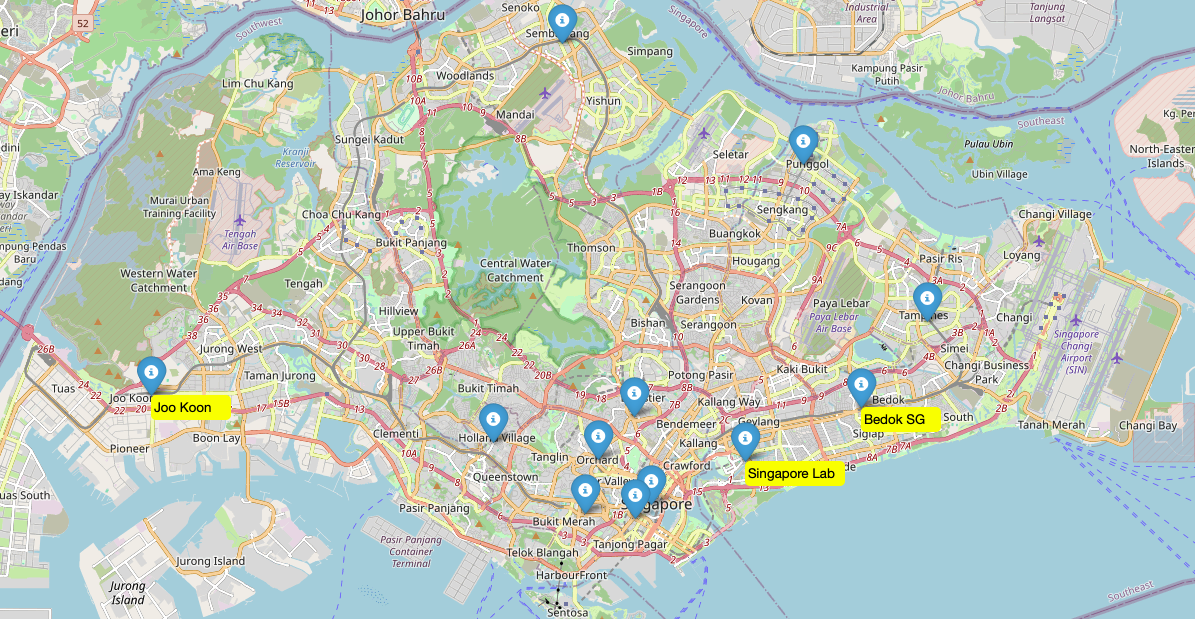

In [39]:
from PIL import Image
from IPython.display import display
img = Image.open("/Users/kohziyang/Documents/GitHub/dec_data/Screenshot 2025-03-24 at 2.07.18 AM.png")
display(img)

From our analysis, we observe that members have a higher average basket value and basket size compared to non-members. This could be due to members taking advantage of member benefits, such as points system or exclusive access, which may encourage them to make larger purchases. Additionally, members might have a greater sense of brand loyalty, leading them to shop more frequently and purchase more items.

Also, we observe that Decathlon Singapore Lab has the highest average basket value and basket size among non-members, while Joo Koon records the highest average basket value and basket size among members.

Decathlon Singapore Lab has the highest average basket value and basket size among non-members, likely due to its location near the stadium, which attracts many sports enthusiasts before or after their workouts. As non-members generally do not have access to membership benefits like discounts or exclusive offers, they may tend to make larger purchases when visiting the store. The proximity to a high-traffic area like a stadium increases footfall, particularly among people who may not regularly shop at Decathlon but are drawn in by the store's location and the immediate need for sports equipment. 

Joo Koon records the highest average basket value and basket size among members, and this can be attributed to several possible factors. First, Joo Koon is the only Decathlon store in the western part of Singapore, making it the primary destination for customers in that region. As it caters to a large geographical area, members who live or work nearby may choose to visit this location more frequently. This consistent foot traffic from members, who are more likely to make repeat purchases, leads to larger basket sizes and higher average values.
Furthermore, the exclusivity of this store may foster a sense of loyalty among local customers. As a result, members may be more inclined to purchase higher-value items or multiple products in a single trip, knowing they have easy access to this store.

Additionally, Bedok has one of the highest transaction counts for both members and non-members. A possible reason for this is its strategic location beside East Coast Park, which attracts many sports enthusiasts who purchase equipment from Decathlon.

### Section B

There are 3 main channels for customers to shop with us: Experience stores, C&C stores and Online. Find the proportion (in %) of members who shopped at each channel exclusively as well as the different possible combinations of channels.

We have a total 3C1 + 3C2 + 3C3 = 7 different combination of channels

Bedok SG


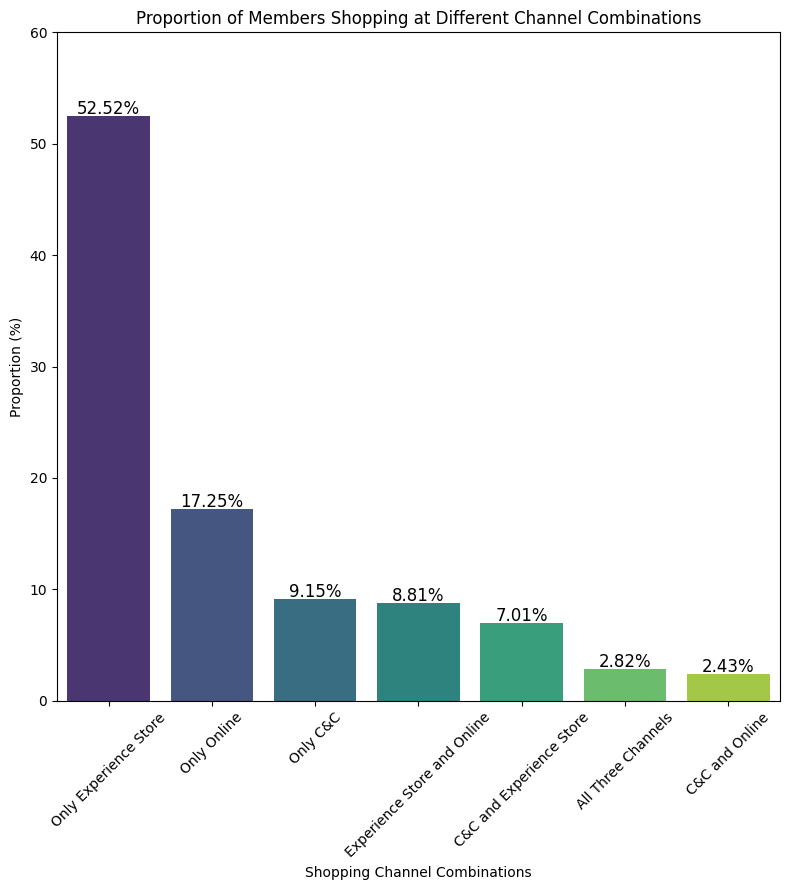

In [40]:
print(store)

#label the store for experience_store, website and Click and Collect” (C&C)
def label(store_name):
    if store_name == "Bedok SG" or store_name == "City Square SG" or store_name == "Joo Koon" or store_name == "Singapore Lab" or store_name == "Centre Point":
        return "experience_store"
    elif store_name == "Website":
        return "web"
    else:
        return "C&C"

df["store_label"] = df["but_name_business_unit"].apply(label)

member1 = df[~df["ctm_customer_id"].isna()]
member = duckdb.query(f"SELECT ANY_VALUE(ctm_customer_id) as ctm_customer_id, ANY_VALUE(store_label) as store_label FROM member1 GROUP BY the_transaction_id").df()

#query for customer that only do one of the channel only
df_cc = duckdb.query("SELECT ctm_customer_id from member GROUP BY ctm_customer_id HAVING COUNT(DISTINCT store_label) = 1 AND SUM(IF(store_label = 'web' OR store_label = 'experience_store' , 1, 0)) = 0").df()
df_exp = duckdb.query("SELECT ctm_customer_id from member GROUP BY ctm_customer_id HAVING COUNT(DISTINCT store_label) = 1 AND SUM(IF(store_label = 'web' OR store_label = 'C&C' , 1, 0)) = 0").df()
df_online = duckdb.query("SELECT ctm_customer_id from member GROUP BY ctm_customer_id HAVING COUNT(DISTINCT store_label) = 1 AND SUM(IF(store_label = 'C&C' OR store_label = 'experience_store' , 1, 0)) = 0").df()


#query for customer that only do both of the channel
df_both_cc_exp = duckdb.query("SELECT ctm_customer_id from member GROUP BY ctm_customer_id HAVING COUNT(DISTINCT store_label) = 2 AND SUM(IF(store_label = 'web' , 1, 0)) = 0").df()
df_both_cc_online = duckdb.query("SELECT ctm_customer_id from member GROUP BY ctm_customer_id HAVING COUNT(DISTINCT store_label) = 2 AND SUM(IF(store_label = 'experience_store' , 1, 0)) = 0").df()
df_both_exp_online = duckdb.query("SELECT ctm_customer_id from member GROUP BY ctm_customer_id HAVING COUNT(DISTINCT store_label) = 2 AND SUM(IF(store_label = 'C&C' , 1, 0)) = 0").df()

#query for customer that did three of the channel
df_all = duckdb.query("SELECT ctm_customer_id from member GROUP BY ctm_customer_id HAVING COUNT(DISTINCT store_label) = 3").df()

#information for the total member count
df_len = duckdb.query("SELECT DISTINCT ctm_customer_id from member").df()


total_customers = len(df_len)
cc_exclusive = round(len(df_cc) / total_customers * 100 ,2)
exp_exclusive = round(len(df_exp) / total_customers * 100 ,2)
online_exclusive = round(len(df_online) / total_customers * 100 ,2)

# Calculate the proportions for each combination of channels
cc_exp_combination = round(len(df_both_cc_exp) / total_customers * 100 ,2)
cc_online_combination = round(len(df_both_cc_online) / total_customers * 100 ,2)
exp_online_combination = round(len(df_both_exp_online) / total_customers * 100 ,2)

# All three channels
all_three_combination = round(len(df_all) / total_customers * 100 ,2)

# Store the results in a dictionary or DataFrame for easy visualization
proportions = {
    'Only C&C': cc_exclusive,
    'Only Experience Store': exp_exclusive,
    'Only Online': online_exclusive,
    'C&C and Experience Store': cc_exp_combination,
    'C&C and Online': cc_online_combination,
    'Experience Store and Online': exp_online_combination,
    'All Three Channels': all_three_combination
}

proportions_df = pd.DataFrame(list(proportions.items()), columns=['Combination', 'Proportion']).sort_values(by = ["Proportion"], ascending = False)


#visulisation

plt.figure(figsize=(8, 9))

ax = sns.barplot(data=proportions_df, x='Combination', y='Proportion', palette='viridis')

plt.xticks(rotation=45)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=12, color='black', 
                xytext=(0, 5), textcoords='offset points')

plt.title('Proportion of Members Shopping at Different Channel Combinations')
plt.xlabel('Shopping Channel Combinations')
plt.ylabel('Proportion (%)')
plt.ylim(0,60)
plt.tight_layout()
plt.show()

In this analysis, we observe that most members have visited either the experience store or shopped online. The combination of C&C (Click & Collect) and online has the least proportion, possibly because members who prefer online shopping may not find the need to visit a physical store for pickup, especially if they value convenience or delivery options. Additionally, the experience store might already provide an immersive shopping experience that reduces the need for an additional C&C option.


# EXTRA SELF EXPLORE

Below is my exploration using a Support Vector Machine (SVM). While this approach has its limitations, my goal is to apply what I’ve learned to a real-world scenario.



Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification and regression tasks. While it can handle regression problems, SVM is particularly well-suited for classification tasks.

SVM aims to find the optimal hyperplane in an N-dimensional space to separate data points into different classes where Support Vectors are the closest data points to the hyperplane.

If you think of the hyperplane as a decision boundary that separates two classes (e.g.,whether the customers are active or not), the support vectors are the data points (customers) closest to this boundary. These are the customers who are most influential in determining the decision of whether or not a conversion will occur.

Thus, customers that are support vectors may have a higher chance of transitioning from one class (e.g., non-converting) to another class (e.g., converting). The closer a customer is to the hyperplane, the more uncertain their classification is, which could imply that their behavior is at a tipping point, making them highly susceptible to conversion with the right interventions.

By identifying these customers as support vectors, businesses can focus efforts on them, such as targeted marketing, personalized offers, or engagement strategies, to increase the likelihood of conversion.



I used SVM to identify:\
Potential non-active customers who could be converted into active customers.\
Potential active customers who might become non-active.

### Load Libraries for Machine Learning

In [41]:
if run:
    from sklearn.model_selection import train_test_split
    from sklearn.svm import SVC  # Support Vector Classifier
    from sklearn.preprocessing import StandardScaler


I have come out with a pivot table with 5 features, count of C&C, count of experience store, count of online, total basket size (from 1 July 2020 to 31 December 2020) and total basket value (from 1 July 2020 to 31 December 2020)

In [42]:
if run:

    member = df[~df["ctm_customer_id"].isna()]
    member_value = duckdb.query("SELECT ctm_customer_id, SUM(f_qty_item) as 'item_purchase', SUM(f_to_tax_in) as 'value_purchase' FROM member GROUP BY ctm_customer_id").df()
    member = member.drop_duplicates(subset = ["the_transaction_id"])
    store_counts = member.groupby(['ctm_customer_id', 'store_label']).size().reset_index(name='count')

    # Pivot the table to get one column for each store type
    pivot_table = store_counts.pivot_table(index='ctm_customer_id', 
                                        columns='store_label', 
                                        values='count', 
                                        aggfunc='sum', 
                                        fill_value=0)  # fill NaNs with 0

    # Rename the columns for easier reference
    pivot_table.columns = ['C&C', 'experience_store', 'online']

    # Reset the index to have member_id as a column
    pivot_table = pivot_table.reset_index()

    pivot_table = pd.merge(pivot_table, member_value, how = "left", on = "ctm_customer_id")


I have added an additional column called 'target', where 1 indicates an Active Customer and 0 indicates a Non-active Customer.\
The criteria for defining these categories were based on my own rules, but the exact definitions can vary depending on the company's needs and domain knowledge

#### According to the Pareto Principle (80-20 rule), 80% of a company's revenue is generated by 20% of its customers. The threshold is set at 78.12, as the proportion of Active Customers to all customers is approximately 20% when this threshold is applied. However, this threshold can be adjusted based on the company's specific knowledge or research."

In [43]:
if run:
    threshold = 78.12
    pivot_table['target'] = 20 * (pivot_table['C&C'] + pivot_table['experience_store'] + pivot_table['online']) + 0.1 * pivot_table["item_purchase"] + 0.01 * pivot_table["value_purchase"]   >= threshold
    pivot_table['target'] = pivot_table['target'].astype(int)
    print(pivot_table["target"].value_counts())


target
0    307914
1     76975
Name: count, dtype: int64


### SVM training 

In [44]:
if run:
    X = pivot_table[['C&C', 'experience_store', 'online', "item_purchase", "value_purchase"]]

    y = pivot_table['target']

    # Split data into training and testing sets (80% training, 20% testing)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Normalize the features to make sure all features are on the same scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train the SVM model
    svm_model = SVC(kernel='rbf') 
    svm_model.fit(X_train_scaled, y_train)

    support_vectors = svm_model.support_vectors_

    # Print the support vectors
    print("Support Vectors:")
    print(support_vectors)
    print(len(support_vectors))

    print("Indices of Support Vectors:")
    print(svm_model.support_)


Support Vectors:
[[-0.41375213  0.75033252 -0.46528472  0.77141304  0.88194058]
 [-0.41375213  0.2299058  -0.46528472  1.44726534  2.25991261]
 [ 0.91882982  0.2299058  -0.46528472 -0.55090669 -0.74041843]
 ...
 [ 0.91882982 -0.29052092  0.46335753  1.0064921   0.98382786]
 [-0.41375213 -0.29052092  2.32064202  0.38940956 -0.12410725]
 [-0.41375213  0.75033252 -0.46528472  0.88895257  0.98596536]]
2260
Indices of Support Vectors:
[   175    443    463 ... 307169 307245 307376]


##### These are the support vectors, which are
##### Potential non-active customers who could be converted into active customers. AND
##### Potential active customers who might become non-active.

In [45]:

if run: 
    print("Support Vectors (Potential non-active customers who could be converted into active customers) :")
    support_vectors_df = pivot_table.iloc[svm_model.support_][pivot_table["target"] == 0]["ctm_customer_id"]
    print(support_vectors_df)


    print("Support Vectors (Potential active customers who might become non-active) :")
    support_vectors_df = pivot_table.iloc[svm_model.support_][pivot_table["target"] == 1]["ctm_customer_id"]
    print(support_vectors_df)





Support Vectors (Potential non-active customers who could be converted into active customers) :
175       00IN101PBZ
443       01CGGSDYP7
463       01EMJWD4U5
1006      03C9DQZ426
1105      03OS45A8PJ
             ...    
304816    SH4JU7KFSN
305362    SIXSM3SIK1
305800    SKFE9MIOK9
307169    SOTAO90I0F
307245    SP389C23M7
Name: ctm_customer_id, Length: 1799, dtype: object
Support Vectors (Potential active customers who might become non-active) :
941       033DFE0VLG
2156      079GU1OLUK
2657      08SH9M8LLV
2727      091X8JZXZC
2960      09V95AFH9M
             ...    
302054    S7ZP2K7KF6
305212    SIE3YXNMZV
305807    SKG9FUBMTM
305957    SKY36IVJLJ
307376    SPKT5B3DAI
Name: ctm_customer_id, Length: 461, dtype: object


### Section C

If there is any timing of the day that is most popular for purchases in stores?


In this analysis, I will exclude three dates—31 July 2020 (Friday), 10 August 2020 (Monday), and 25 December 2020 (Friday)—as they are official public holidays in Singapore. To eliminate bias, I have accounted for these holidays in the dataset. Additionally, public holidays that fall on a Sunday have already been considered, as the following Monday is designated as a public holiday.




Identify the number of days from 1 July 2020 to 31 December 2020 

In [47]:
fre = {}

mondays = pd.date_range(start="2020-07-01", end="2020-12-31", freq="W-MON")
fre[0] = len(mondays) - 1
print(len(mondays) - 1)

tue = pd.date_range(start="2020-07-01", end="2020-12-31", freq="W-TUE")
fre[1] = len(tue)
print(len(tue))

wed = pd.date_range(start="2020-07-01", end="2020-12-31", freq="W-WED")
fre[2] = len(wed)
print(len(wed))


thu = pd.date_range(start="2020-07-01", end="2020-12-31", freq="W-THU")
fre[3] = len(thu)
print(len(thu))

fri = pd.date_range(start="2020-07-01", end="2020-12-31", freq="W-FRI")
fre[4] = len(fri) - 2
print(len(fri) - 2)

sat = pd.date_range(start="2020-07-01", end="2020-12-31", freq="W-SAT")
fre[5] = len(sat)
print(len(sat))

sun = pd.date_range(start="2020-07-01", end="2020-12-31", freq="W-SUN")
fre[6] = len(wed)
print(len(sun))
fre

25
26
27
27
24
26
26


{0: 25, 1: 26, 2: 27, 3: 27, 4: 24, 5: 26, 6: 27}

Drop the dates mentioned earlier and convert DateTime into separate weekday and hour columns.

In [48]:
df_store = df
df_store = df_store[(df_store["the_date_transaction"] != "2020-07-31") & (df_store["the_date_transaction"] != "2020-08-10") & (df_store["the_date_transaction"] != "2020-12-25")]
df_store = df_store[df_store["store_label"] != "web"]
df_store["hour"] = df_store["the_date_transaction"].dt.hour
df_store["weekday"] = df_store["the_date_transaction"].dt.day_of_week

df_store = df_store.drop_duplicates(subset = ["the_transaction_id"])

df_store = df_store[df_store["hour"] >= 9]



Group Week and hour together

In [49]:
transaction_counts = df_store.groupby(['weekday', 'hour']).size().reset_index(name='count')

Visualisation

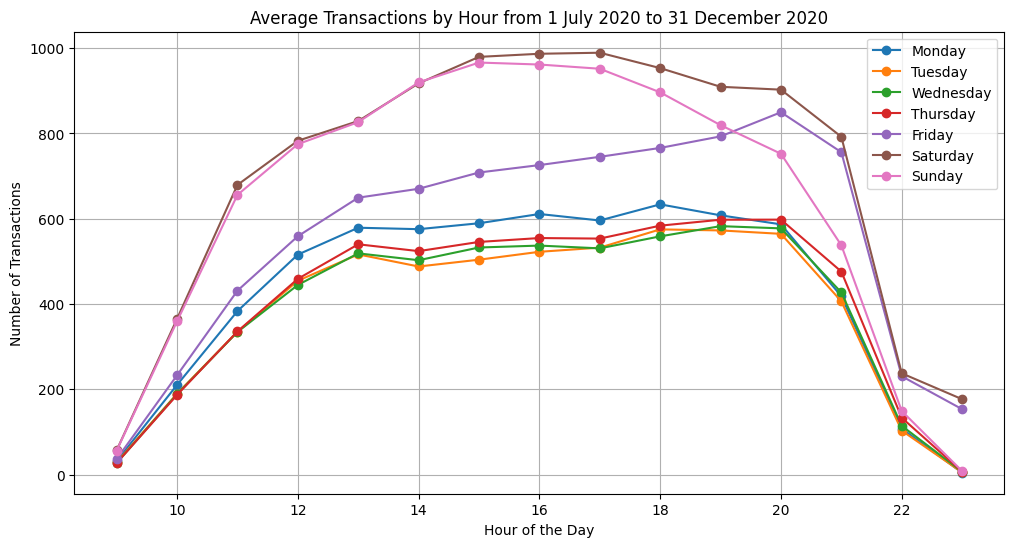

In [50]:
# Define weekday labels
weekday_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Plot
plt.figure(figsize=(12, 6))

for weekday in range(7):  # Loop through each weekday
    subset = transaction_counts[transaction_counts['weekday'] == weekday]
    plt.plot(subset['hour'], subset['count'] / fre[weekday], marker='o', label=weekday_labels[weekday])


plt.xlim = (9,23)
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Transactions")
plt.title("Average Transactions by Hour from 1 July 2020 to 31 December 2020")  # Ensure all hours are displayed
plt.legend()
plt.grid(True)
plt.show()



The graph shows that peak hours on weekends occur between 14:00 and 18:00. However, on Fridays, there is an additional peak at 20:00, indicating that people tend to shop after work.

The early morning (09:00 - 10:00) and late evening (after 22:00) show lower transaction volumes, which is typical as these are off-peak hours.

If the business aims to maximize transactions, it might consider offering promotions during slower periods to boost activity. (Like weekday lunch meal for restaurants)

Targeted marketing campaigns could also be scheduled around peak transaction times to capitalize on higher customer engagement.